# 01 — Data overview

Load the 2025 senatorial dataset, look at turnout and vote distributions, and
run the standard preprocessing (region exclusion, candidate/precinct filters,
normalization). Replaces the exploratory `eda_elections_2025` /
`vca_elections_2025` notebook cells.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [2]:
from src.data import load_complete

df = load_complete(config)
print(df.shape)
df.head(3)

(92822, 83)


,REGION,PROVINCE,CITY_MUNICIPALITY,BARANGAY,CLUSTERED_PRECINCT,PRECINCT_CLUSTER,CLUSTERTOTAL,POLLING_PLACE,information.abstentions,information.numberOfRegisteredVoters,...,"57. SAHIDULLA, NUR-ANA (IND)","58. SALVADOR, PHILLIP IPE (PDPLBN)","59. SOTTO, TITO (NPC)","60. TAPADO, MICHAEL BONGBONG (PM)","61. TOLENTINO, FRANCIS TOL (PFP)","62. TULFO, BEN BITAG (IND)","63. TULFO, ERWIN (LAKAS)","64. VALBUENA, MAR MANIBELA (IND)","65. VERCELES, LEANDRO (IND)","66. VILLAR, CAMILLE (NP)"
0,CAR,ABRA,BANGUED,ZONE 1 POB.,1010001,"0001A, 0004A, 0004B",545,BANGUED WEST CENTRAL SCHOOL,0.0,545.0,...,3.0,44.0,168.0,6.0,67.0,137.0,188.0,4.0,4.0,118.0
1,CAR,ABRA,BANGUED,ZONE 1 POB.,1010002,"0002A, 0003A, 0005A, 0005B",784,BANGUED WEST CENTRAL SCHOOL,0.0,784.0,...,2.0,60.0,205.0,6.0,90.0,190.0,279.0,2.0,1.0,196.0
2,CAR,ABRA,BANGUED,ZONE 2 POB.,1010003,"0006A, 0009A, 0010A",490,BANGUED WEST CENTRAL SCHOOL,0.0,490.0,...,2.0,31.0,147.0,1.0,86.0,80.0,192.0,3.0,1.0,147.0


## Turnout summary

In [3]:
total_registered = df['CLUSTERTOTAL'].sum()
total_actual = df['information.numberOfActuallyVoters'].sum()
print(f'Registered voters: {total_registered:,.0f}')
print(f'Actual voters:     {total_actual:,.0f}')
print(f'Turnout:           {total_actual / total_registered:.2%}')

Registered voters: 69,298,802
Actual voters:     56,972,293
Turnout:           82.21%


## Voters per precinct — local vs. overseas

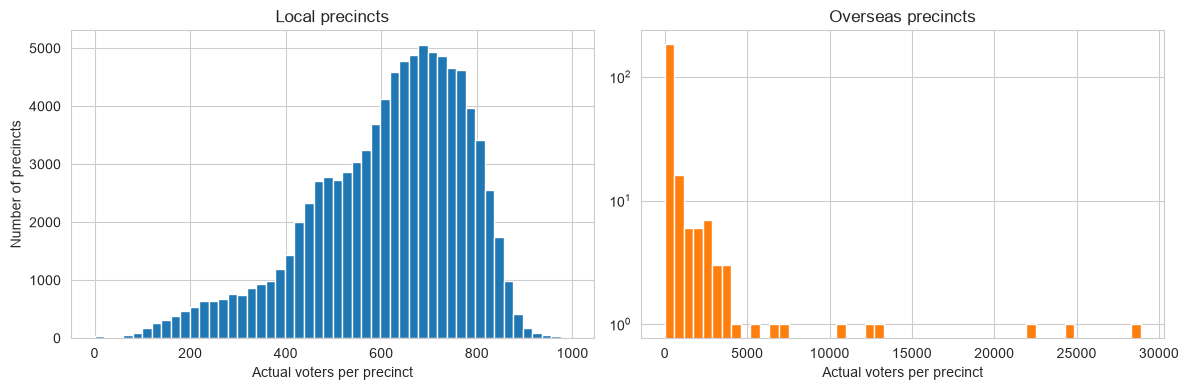

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[df.REGION != 'OV']['information.numberOfActuallyVoters'].hist(
    bins=50, ax=axes[0], color='C0', edgecolor='white')
axes[0].set_xlabel('Actual voters per precinct')
axes[0].set_ylabel('Number of precincts')
axes[0].set_title('Local precincts')

df[df.REGION == 'OV']['information.numberOfActuallyVoters'].hist(
    bins=50, ax=axes[1], color='C1', edgecolor='white')
axes[1].set_xlabel('Actual voters per precinct')
axes[1].set_title('Overseas precincts')
axes[1].set_yscale('log')
fig.tight_layout()

## Barangay-level turnout (complementary cumulative)

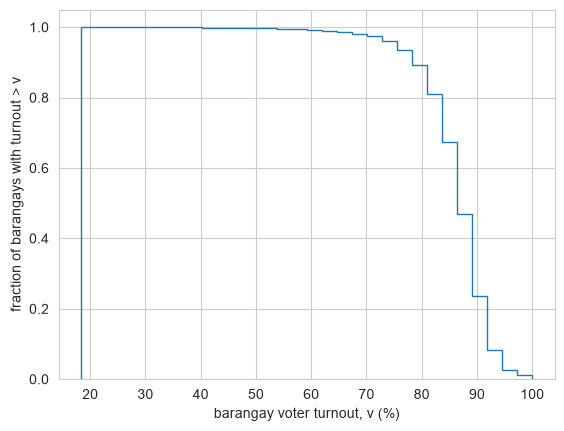

In [5]:
adm = ['REGION', 'PROVINCE', 'CITY_MUNICIPALITY', 'BARANGAY']
local = df[~df.REGION.isin(['OV', 'LAV'])]
by_bgy = local.groupby(adm)
bgy_turnout = 100 * (by_bgy['information.numberOfActuallyVoters'].sum()
                     / by_bgy['information.numberOfRegisteredVoters'].sum())
bgy_turnout.hist(bins=30, cumulative=-1, density=True, histtype='step', color='C0')
plt.xlabel('barangay voter turnout, v (%)')
plt.ylabel('fraction of barangays with turnout > v');

## Standard preprocessing

Parameters come from `configs/config.ini` `[preprocessing]`; see
`src/data/preprocessing.py` for the definitions.

In [6]:
from src.data.preprocessing import preprocess_from_config

pre = preprocess_from_config(df, config)
Y = pre.Y

candidates: 66 -> 42 (25th pct >= 10.0)
precincts:  92,488 -> 92,486 (total votes >= 10.0)
Y: 42 candidates x 92,486 precincts (valid_ballots normalization)


## Top candidates by national total

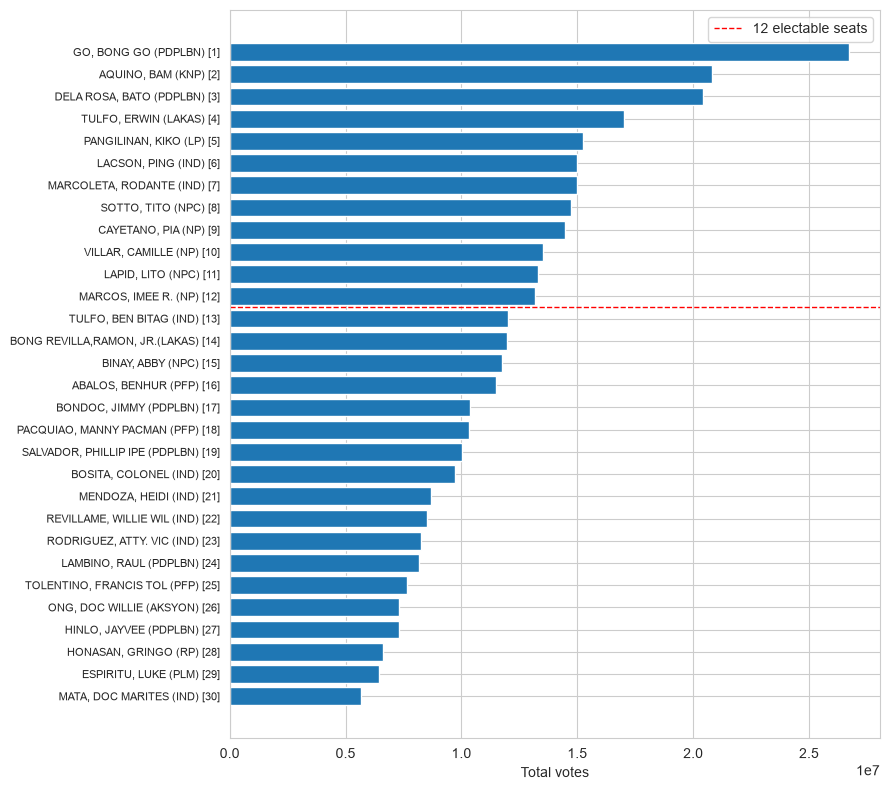

In [7]:
totals = df.loc[~df.REGION.isin(['OV', 'LAV']), pre.ranked_columns].sum()

fig, ax = plt.subplots(figsize=(9, 8))
n_show = 30
y_pos = np.arange(n_show)
ax.barh(y_pos, totals.values[:n_show], color='C0', edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(pre.candidate_labels[:n_show], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Total votes')
ax.axhline(y=11.5, color='red', ls='--', lw=1, label='12 electable seats')
ax.legend()
fig.tight_layout()

## Per-candidate vote-share distributions (top 12)

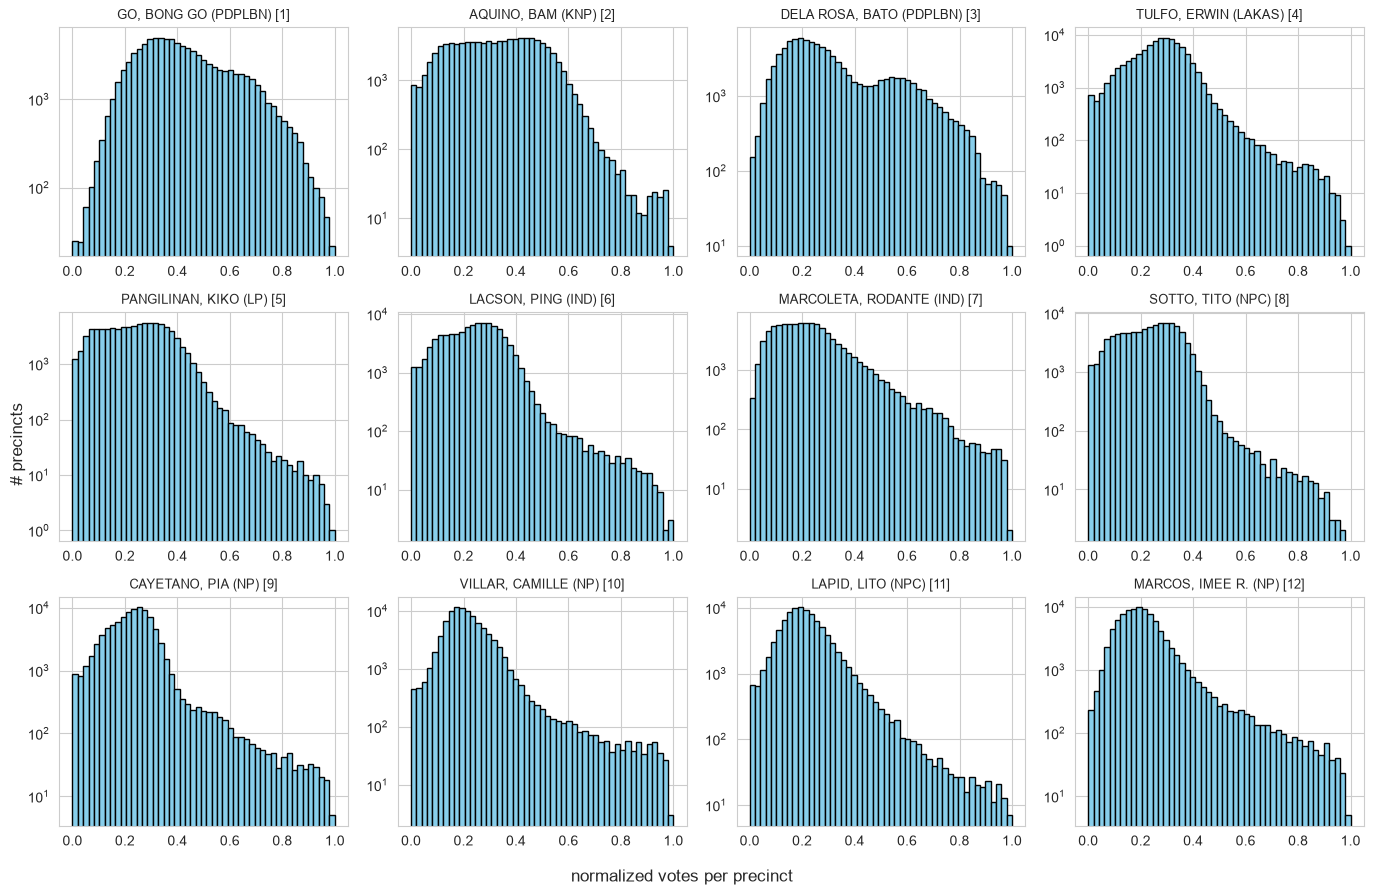

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
bins = np.linspace(0, np.nanmax(Y[:12]), 50)
for i, ax in enumerate(axes.flatten()):
    ax.hist(Y[i, :], bins=bins, color='skyblue', edgecolor='black')
    ax.set_title(pre.candidate_labels[i], fontsize=9)
    ax.set_yscale('log')
fig.supxlabel('normalized votes per precinct')
fig.supylabel('# precincts')
fig.tight_layout()